In [1]:
OPENAI_KEY = "INSERT_KEY"
GEMINI_KEY = "INSERT_KEY"
CLAUDE_KEY = "INSERT_KEY"

In [3]:
import os, re, time
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import google.generativeai as genai
from sentence_transformers import SentenceTransformer

# --- 2. UTILITY FUNCTIONS ---
def super_clean_id(filename):
    nums = re.findall(r"(\d+)", str(filename))
    return str(int(nums[-1])) if nums else str(filename).split('.')[0].strip().lower()

def load_dir_robust(folder):
    texts = {}
    if not folder.is_dir(): return texts
    for fn in os.listdir(folder):
        if fn.lower().endswith(".txt"):
            eid = super_clean_id(fn)
            with open(folder / fn, "r", encoding="utf-8", errors="ignore") as f:
                texts[eid] = f.read().strip()
    return texts

def get_embeddings_batched(text_list, model_id):
    if "models/" in model_id:
        result = genai.embed_content(model=model_id, content=text_list, task_type="clustering")
        return np.array(result['embedding'])
    return SentenceTransformer(model_id).encode(text_list, show_progress_bar=False)


# --- 1. CONFIGURATION ---
genai.configure(api_key=GEMINI_KEY)

ARGREWRITE_ROOT = Path("../ArgRewrite").resolve()
D1_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft1"
D2_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft2"

EMBEDDING_MODELS = {
    "MiniLM-L6": "all-miniLM-L6-v2",
    "Gemini-004": "models/text-embedding-004"
}
# CUSTOMIZE LLM NAMES HERE
# Format: "FOLDER_NAME_UPPER": "Display Name"

# --- 1. CONFIGURATION ---
LLM_DISPLAY_NAMES = {
    "CLAUDE-HAIKU-4-5-20251001": "claude 3.5 haiku",
    "GEMINI-2.5-FLASH": "gemini 2.5 flash",
    "GPT-5-MINI": "gpt-5-mini",
    # "GPT-4O-MINI": "gpt-4o-mini"
}

VARIANT_COLORS = {
    "minimal": "#d95f02", "grammar": "#1b9e77", "general": "#b2182b",
    "completion": "#ce1256", "expansion": "#7570b3"
}

DESCRIPTIVE_NAMES = {
    "minimal": "Minimal Edit", "grammar": "Grammar Edits",
    "completion": "Completion", "expansion": "Expansion", "general": "General Revision",
}

PLOT_ORDER = ["general", "minimal", "grammar", "completion", "expansion"]

# --- 3. DATA AGGREGATION ---
d1_map, d2_map = load_dir_robust(D1_PATH), load_dir_robust(D2_PATH)
common_ids = sorted(set(d1_map.keys()) & set(d2_map.keys()), key=lambda x: int(x))
df_human = pd.DataFrame([{"essay_id": eid, "draft1": d1_map[eid], "draft2": d2_map[eid]} for eid in common_ids])

MODEL_DIRS = [p for p in Path(".").iterdir() if p.is_dir() and p.name.startswith("llm_drafts")]
all_data_list = []

for folder in MODEL_DIRS:
    model_tag = folder.name.replace("llm_drafts_", "").upper()
    for csv_path in folder.glob("*.csv"):
        v_key = "general" if any(x in csv_path.name.lower() for x in ["expert", "general"]) \
                else next((v for v in PLOT_ORDER if v in csv_path.name.lower()), None)
        if not v_key: continue
        ldf = pd.read_csv(csv_path)
        ldf['essay_id'] = ldf['essay_id'].apply(super_clean_id)
        ai_col = 'output_text' if 'output_text' in ldf.columns else 'final_llm_text'
        merged = pd.merge(df_human, ldf[['essay_id', ai_col]], on='essay_id').rename(columns={ai_col: 'ai_text'})
        merged['llm_model'], merged['mode'] = model_tag, v_key
        merged['feedback'] = "WITH" if "with_FB" in csv_path.name else "WITHOUT"
        all_data_list.append(merged)

df_master = pd.concat(all_data_list)


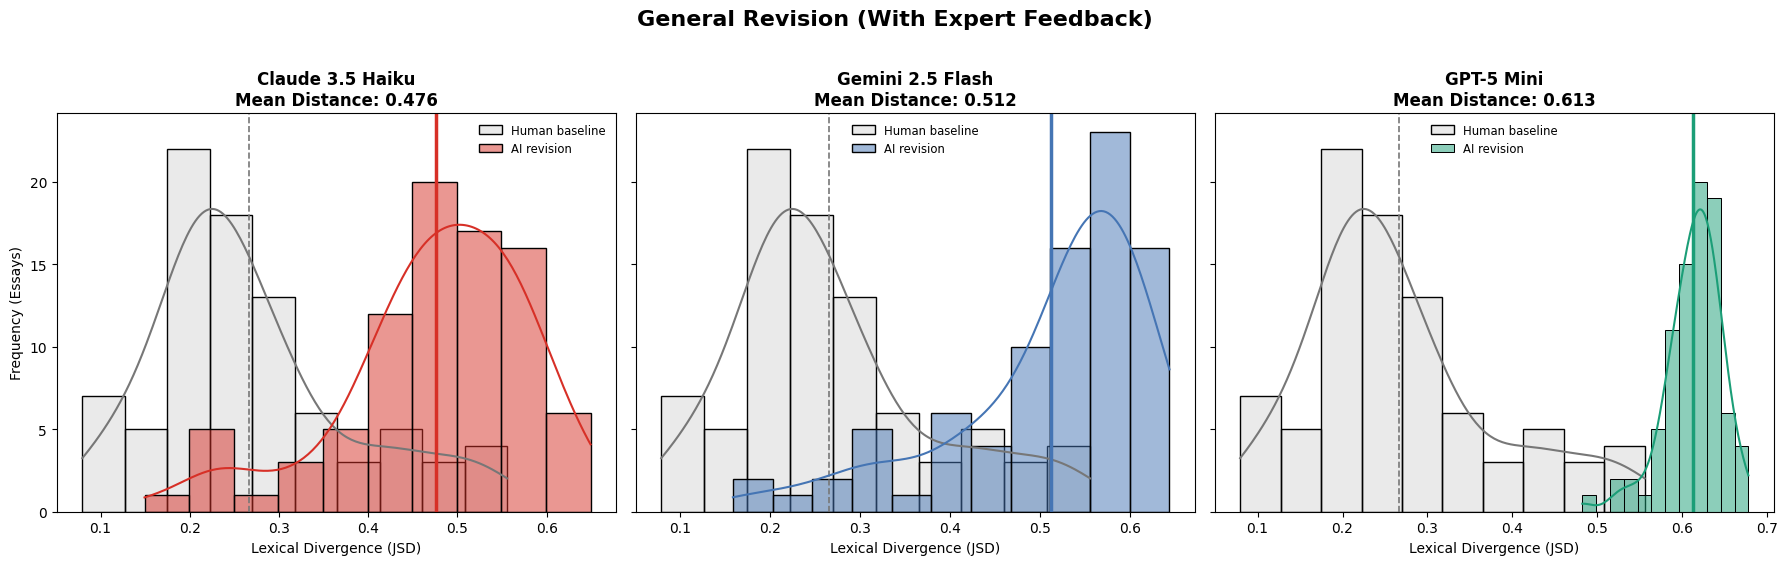

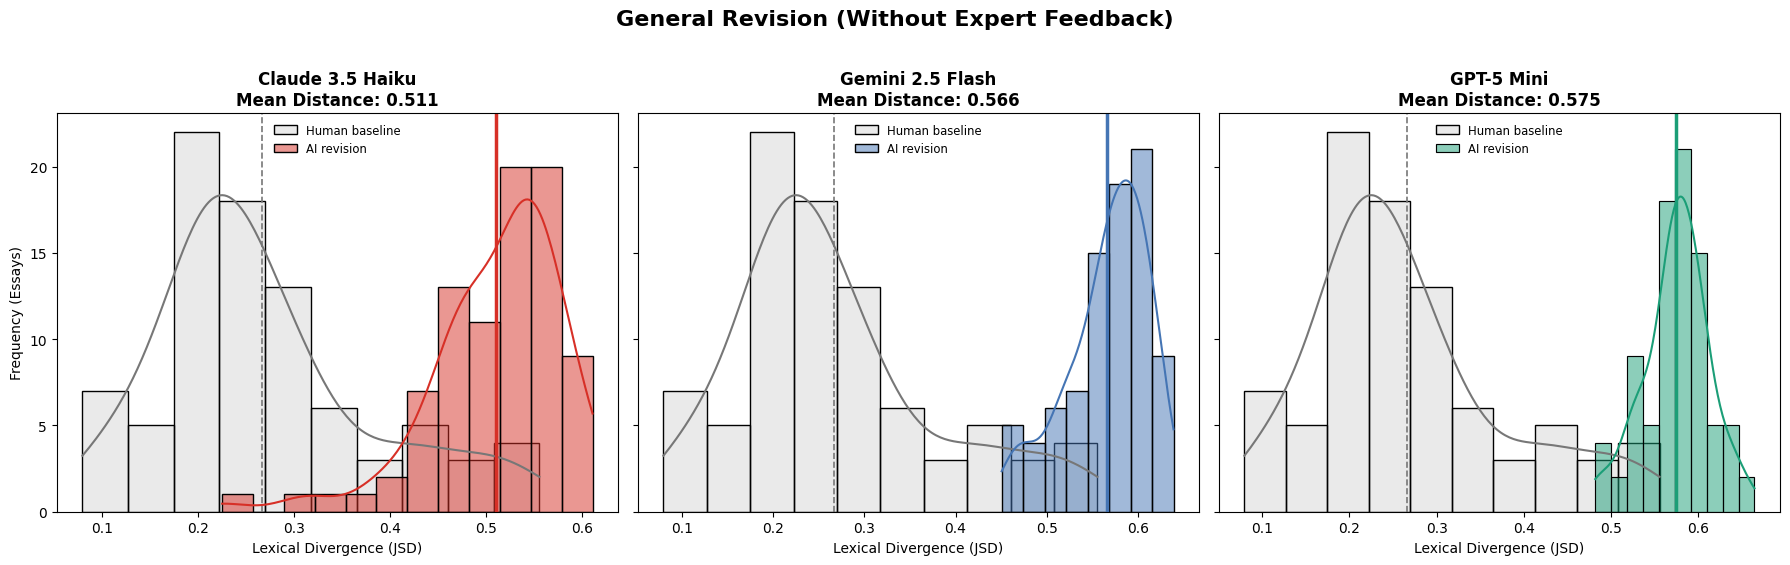

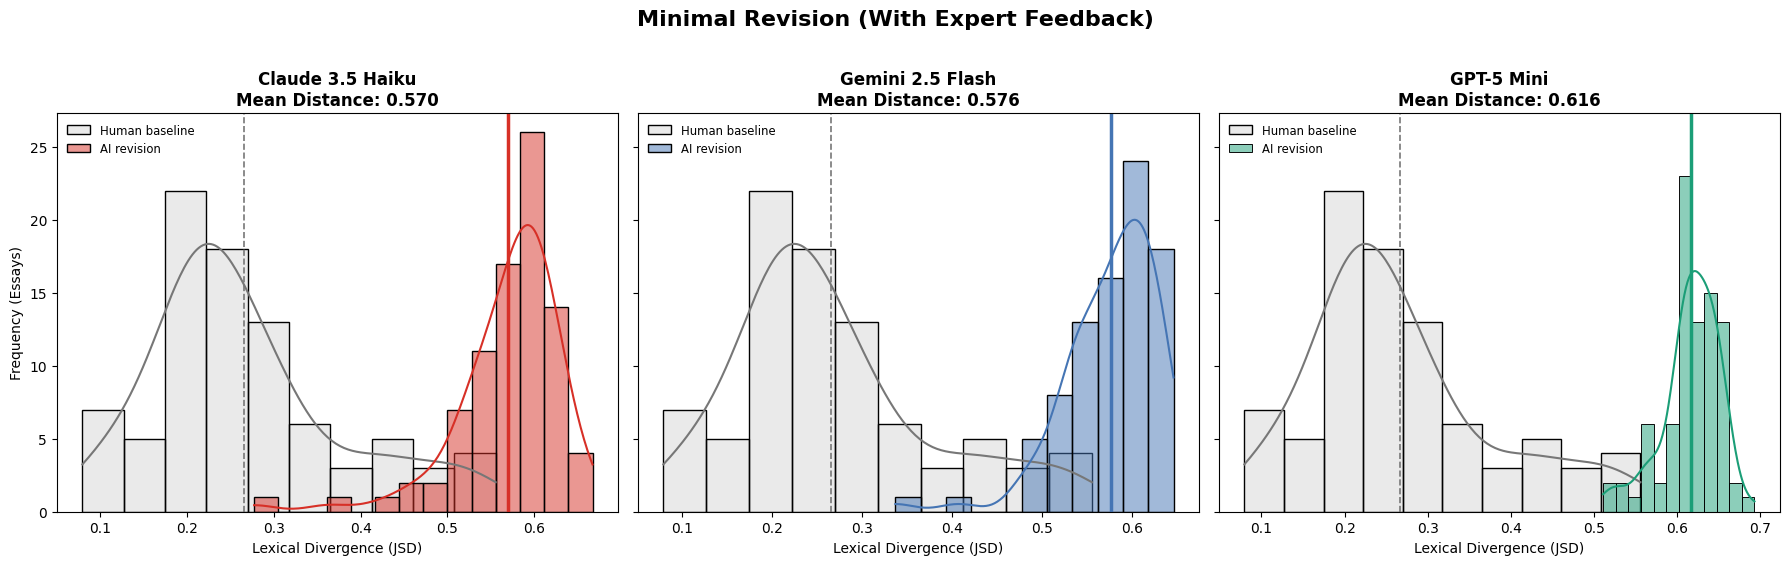

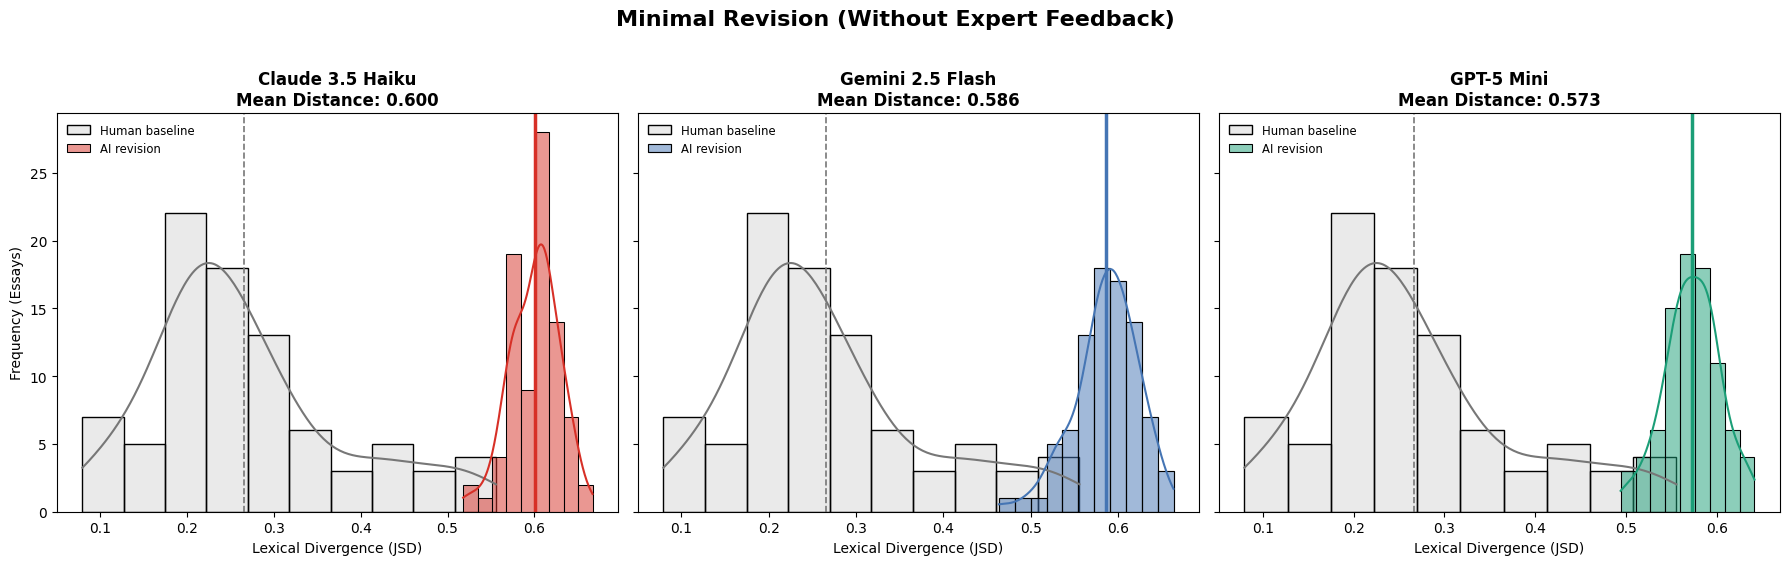

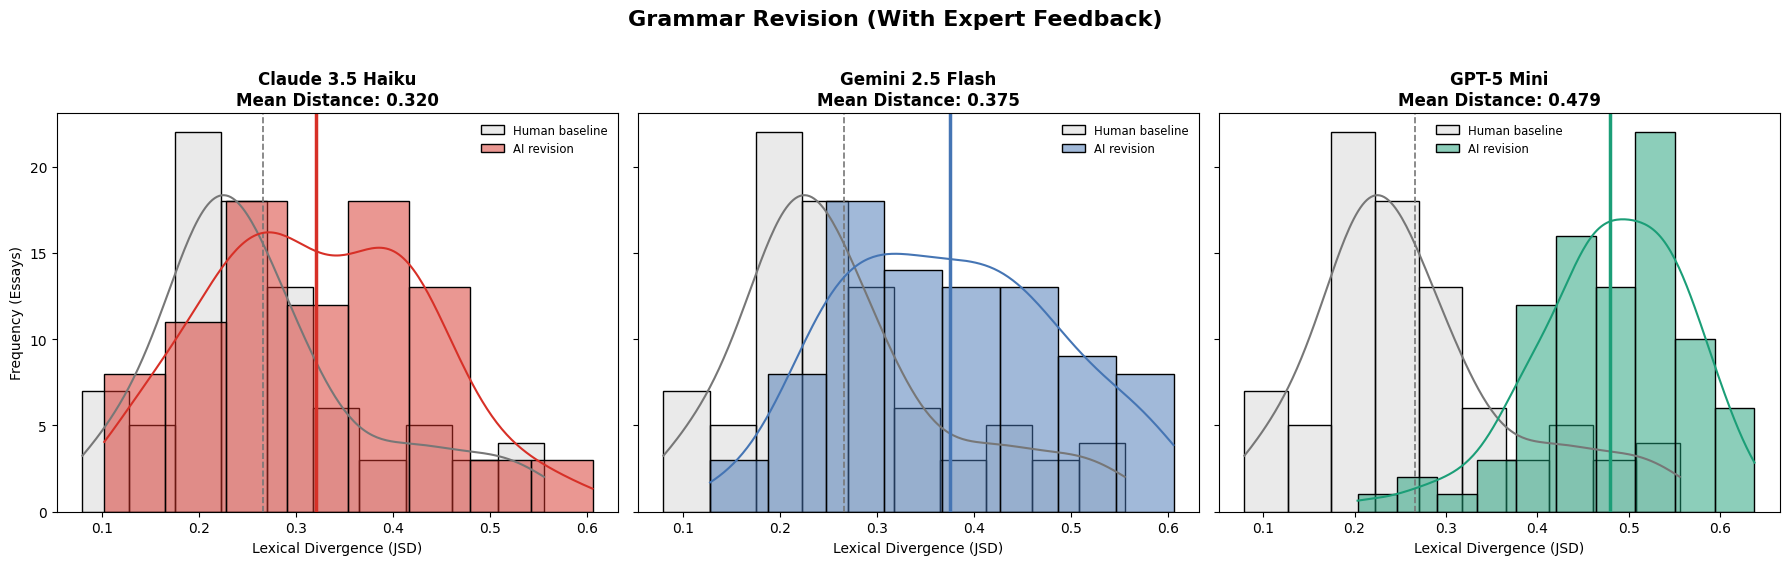

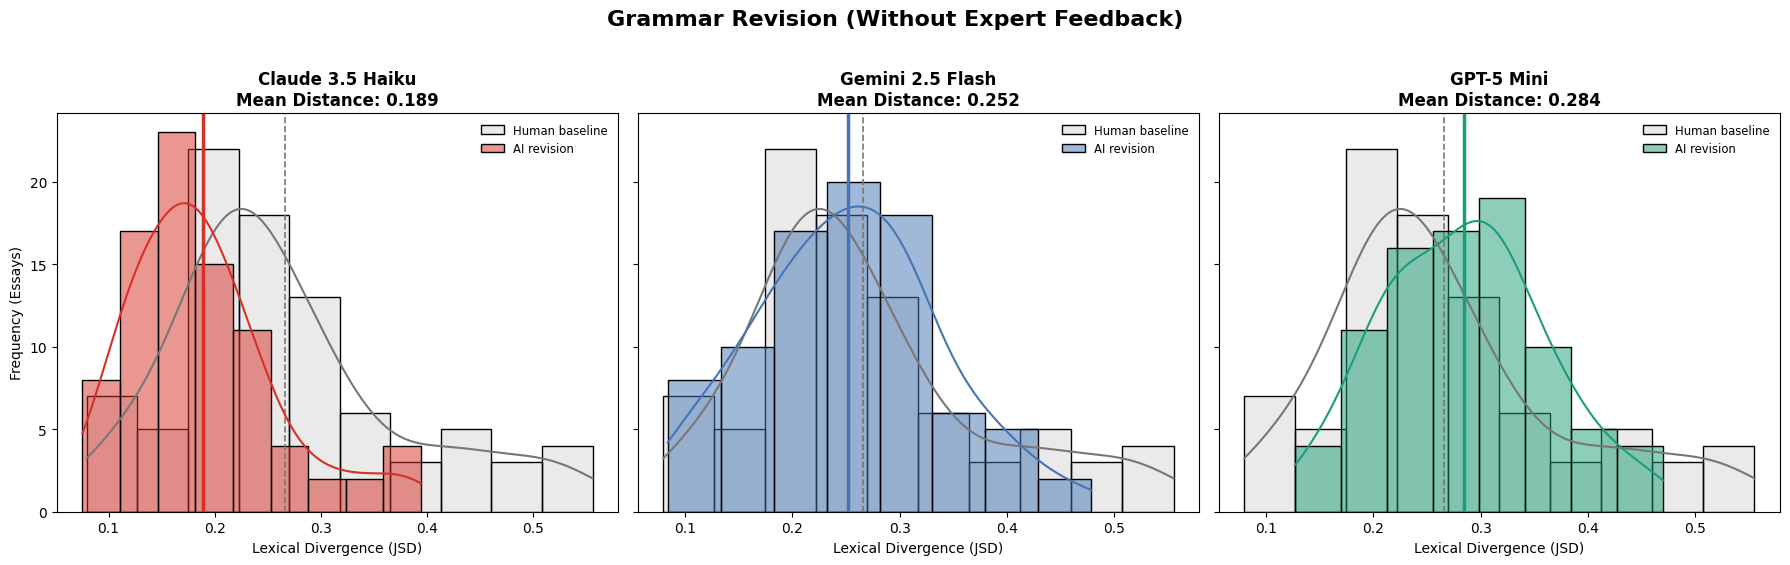

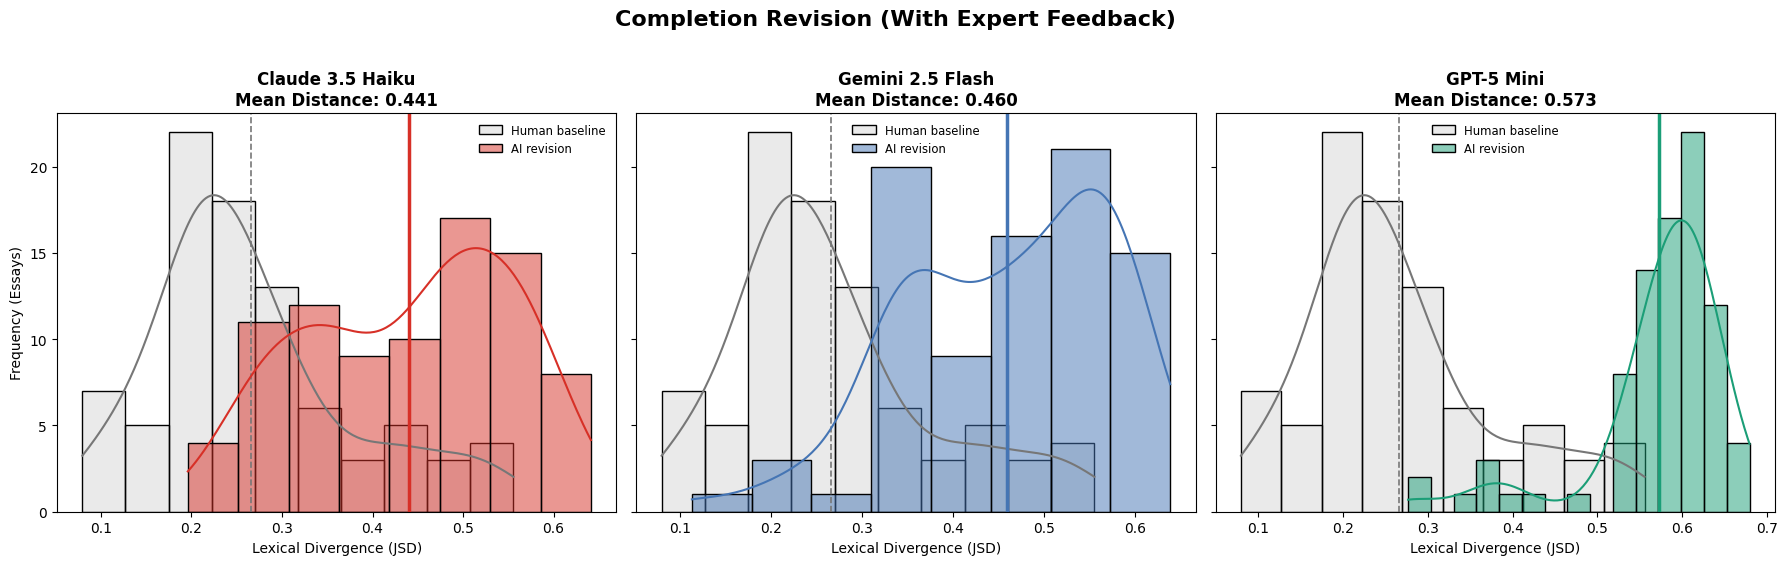

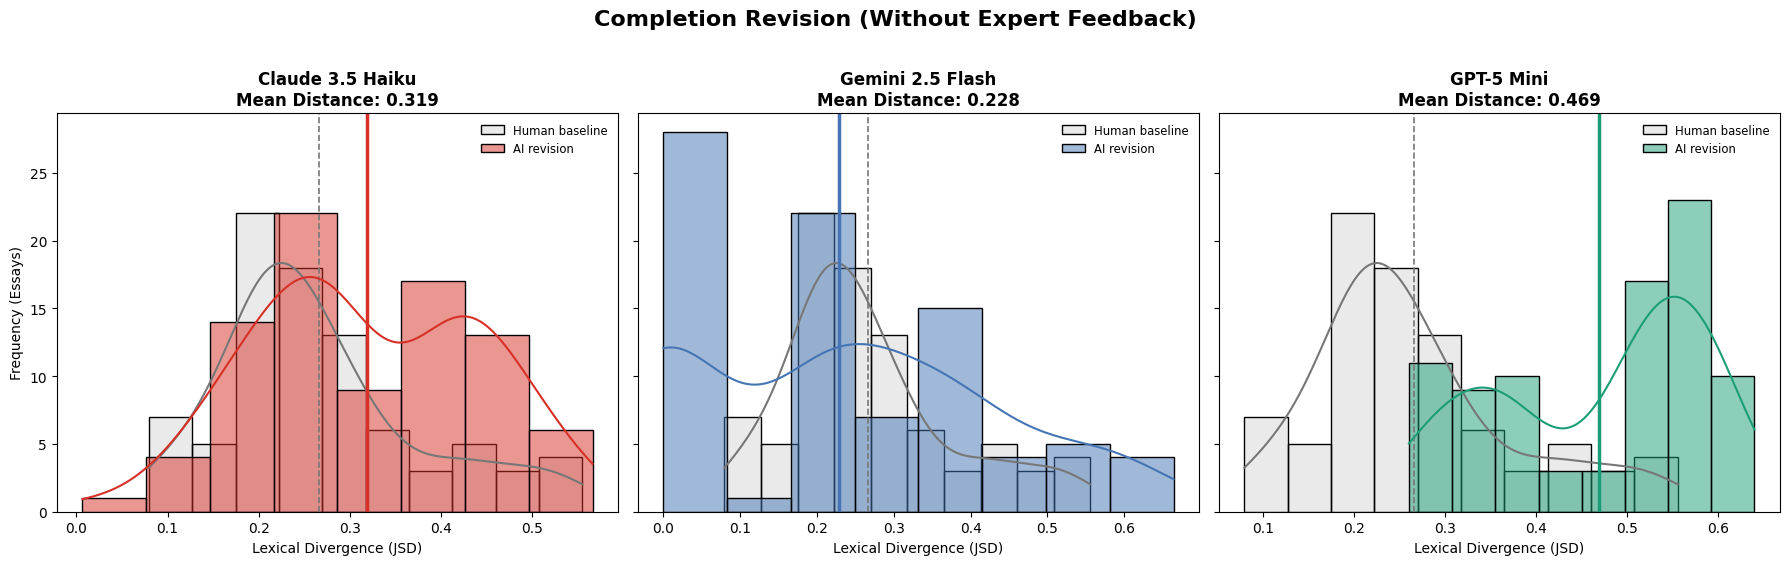

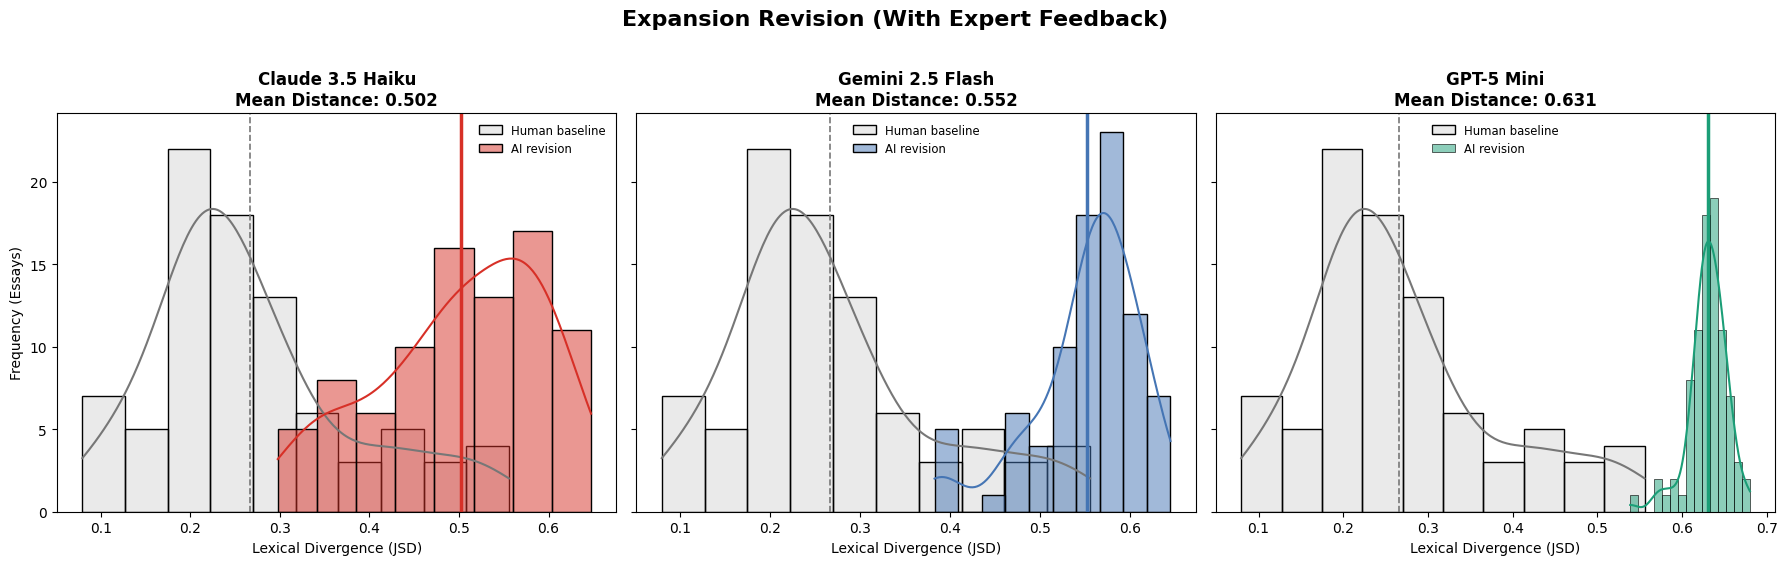

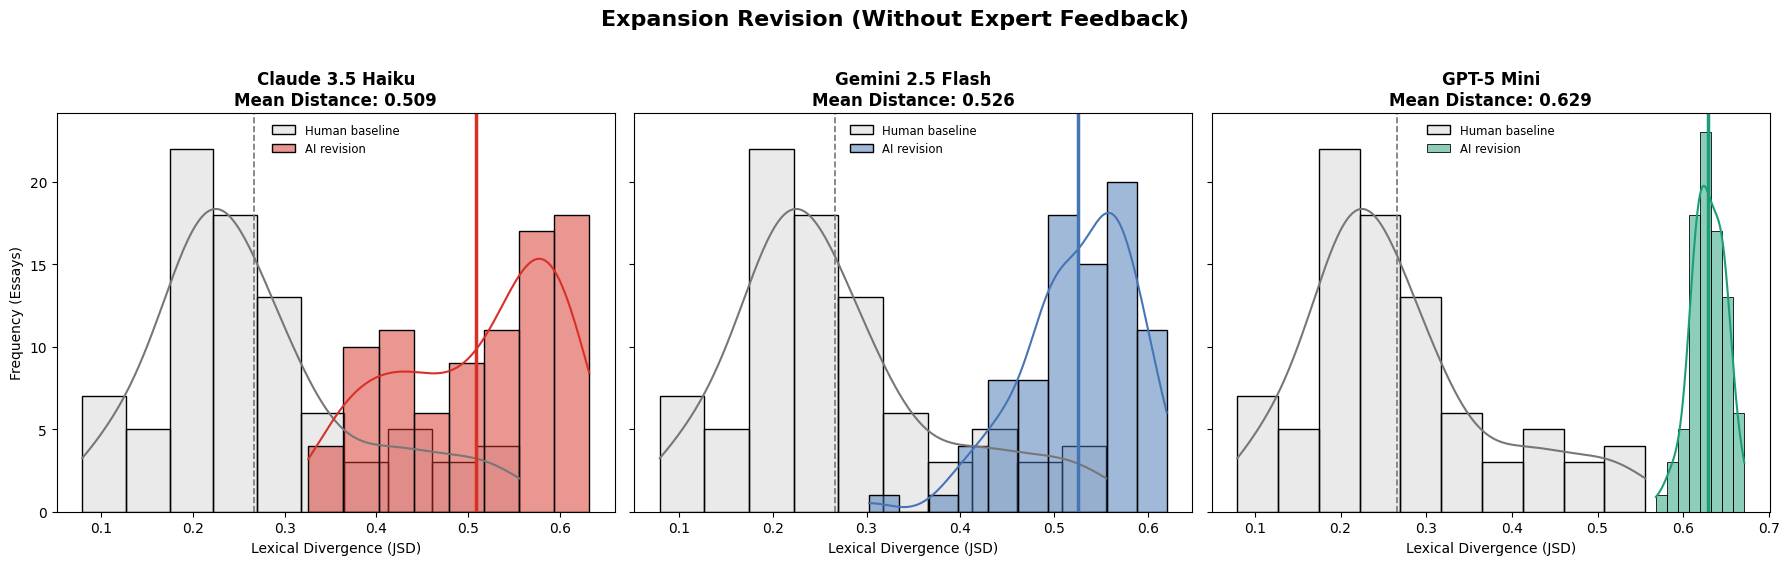

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
TARGET_MODELS = ["CLAUDE-HAIKU-4-5-20251001", "GEMINI-2.5-FLASH", "GPT-5-MINI"]

COLOR_MAP = {
    "Human": "#777777",
    "CLAUDE-HAIKU-4-5-20251001": "#d73027",  # Red
    "GEMINI-2.5-FLASH": "#4575b4",           # Blue
    "GPT-5-MINI": "#1b9e77"                  # Green
}

LLM_DISPLAY_NAMES = {
    "CLAUDE-HAIKU-4-5-20251001": "Claude 3.5 Haiku",
    "GEMINI-2.5-FLASH": "Gemini 2.5 Flash",
    "GPT-5-MINI": "GPT-5 Mini"
}

from scipy.spatial.distance import jensenshannon
from collections import Counter

def calculate_jsd(text1, text2):
    # 1. Simple tokenization
    tokens1 = str(text1).lower().split()
    tokens2 = str(text2).lower().split()
    
    # 2. Get combined vocabulary
    vocab = set(tokens1) | set(tokens2)
    
    # 3. Create frequency vectors
    counts1 = Counter(tokens1)
    counts2 = Counter(tokens2)
    
    # 4. Convert to probability distributions
    p = np.array([counts1[word] for word in vocab])
    q = np.array([counts2[word] for word in vocab])
    
    # Normalize to sum to 1
    p = p / p.sum() if p.sum() > 0 else p
    q = q / q.sum() if q.sum() > 0 else q
    
    # 5. Return JSD (returns value between 0 and 1)
    return jensenshannon(p, q)

# --- 2. PLOTTING FUNCTION ---
def plot_triple_semantic_distribution(mode, fb_status, df_master, df_h):
    # Filter for the specific mode and feedback type
    subset = df_master[(df_master['mode'] == mode) & (df_master['feedback'] == fb_status)]
    
    # Pre-calculate Human JSDs once for the baseline
    h_jsds = [calculate_jsd(r['draft1'], r['draft2']) for _, r in df_h.iterrows()]
    h_mean = np.mean(h_jsds)
    h_color = COLOR_MAP["Human"]

    # Create 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
    
    for i, model_id in enumerate(TARGET_MODELS):
        ax = axes[i]
        m_color = COLOR_MAP.get(model_id, "#999999")
        m_label = LLM_DISPLAY_NAMES.get(model_id, model_id)

        # 1. Plot Human Benchmark (Background)
        sns.histplot(h_jsds, kde=True, ax=ax, color=h_color, alpha=0.15, label='Human baseline')
        ax.axvline(h_mean, color=h_color, linestyle='--', linewidth=1.2)

        # 2. Plot Targeted AI Distribution
        m_data = subset[subset['llm_model'] == model_id]
        if not m_data.empty:
            m_jsds = [calculate_jsd(r['draft1'], r['ai_text']) for _, r in m_data.iterrows()]
            m_mean = np.mean(m_jsds)
            
            sns.histplot(m_jsds, kde=True, ax=ax, color=m_color, alpha=0.5, label=f'AI revision')
            ax.axvline(m_mean, color=m_color, linewidth=2.5)
            
            ax.set_title(f"{m_label}\nMean Distance: {m_mean:.3f}", fontweight='semibold', fontsize=12)
        else:
            ax.set_title(f"{m_label}\n(No data)", color='gray', fontstyle='italic')

        ax.set_xlabel("Lexical Divergence (JSD)")
        if i == 0:
            ax.set_ylabel("Frequency (Essays)")
        
        ax.legend(fontsize='small', frameon=False)

    # NICER TITLE FORMATTING
    # Convert "general" -> "General revision" and align feedback strings
    clean_mode = mode.replace("_", " ").capitalize()
    clean_mode += " Revision"
        
    fb_label = "With Expert Feedback" if fb_status == "WITH" else "Without Expert Feedback"
    
    plt.suptitle(f"{clean_mode} ({fb_label})", 
                 fontsize=16, y=1.02, fontweight='bold', fontfamily='sans-serif')
    
    plt.tight_layout()
    plt.show()

# --- 3. EXECUTION ---
if 'df_master' in locals() and not df_master.empty:
    for mode in PLOT_ORDER:
        for fb in ["WITH", "WITHOUT"]:
            plot_triple_semantic_distribution(mode, fb, df_master, df_human)